In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [16]:
data= pd.read_csv("/Users/akashdeepsangwan/Desktop/ML/ML/GitHub-Collab/Machine-Learning/K-mean_Clusturing/Wholesale customers data.csv")
X= data.copy()

In [5]:
# the data is already cleaned + no-null values

from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

In [15]:
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns, index = X.index)
X_scaled_df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.448652,0.590668,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,1.448652,0.590668,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,1.448652,0.590668,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,-0.690297,0.590668,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,1.448652,0.590668,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


### Process of DBSCAN
- For each data point it look for it's neighbours. To find the neighbours it uses "radius query" {KD Tree/Ball Tree/Brute Force} it gives all the points within the (eps) Note : we don't use KNN here!
- if the data points in the provided eps is more than >= min_samples than it's a core points
- if Circle A has the core points and one it's member B is a core points too. Both will be combined to one cluster . This way core points chain continues and all the clusters can be combined. This also leads to "non-linear" cluster shapes!
- Circle with border points don't have the capability to extend the cluster. However it can be combined to core points clusters.


### Applying DBSCAN 
- First choose the min_sample, the approach we can use : min_sample = 2 * no. of features
- Then find the EPS and apply the DBSCAN


In [17]:
min_samples = 2* X_scaled_df.shape[1]
print(min_samples)

16


- Find the distance of each point to all other points 
- Arrange the distances in ascending order and choose the `min-sample`th distance 
- All these `min-sample`th distances will go on the Y axis
- X-axis contains the range of data points in the dataset

In [ ]:
# k-distance plot to chose eps
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors = min_samples)
nn.fit(X_scaled_df)
distances, _ = nn.kneighbors(X_scaled_df) # distances and indices - both are nested arrays
k_dist = np.sort(distances[:, min_samples-1])
# out of these 16 distances we chose the `min_sample`th for each data points 
# so each data point has one distance now and we sort them out and their range is plotted on the y-axis



In [22]:
print(distances)

[[0.         0.46098501 0.49746796 ... 0.90157956 0.92092344 0.92905695]
 [0.         0.43048153 0.43131993 ... 0.70532678 0.71730557 0.74142647]
 [0.         1.59003936 1.63859769 ... 2.16240185 2.17272497 2.1728031 ]
 ...
 [0.         0.81088341 1.05002533 ... 2.13549175 2.16731561 2.16751755]
 [0.         0.31430896 0.33460941 ... 0.6053585  0.61107798 0.6129737 ]
 [0.         0.1811683  0.26121553 ... 0.3811516  0.38753464 0.38891067]]


In [ ]:
print(_) # these are indices of the 16th distances for each data points

[[  0   5 281 ... 108  20 164]
 [  1  82 396 ... 281   7 123]
 [  2 166  24 ... 415 341   1]
 ...
 [437  77 163 ...  46   9 165]
 [438 429 161 ... 122 374 134]
 [439  34 355 ... 135  98 361]]


In [25]:
print(len(k_dist))

440


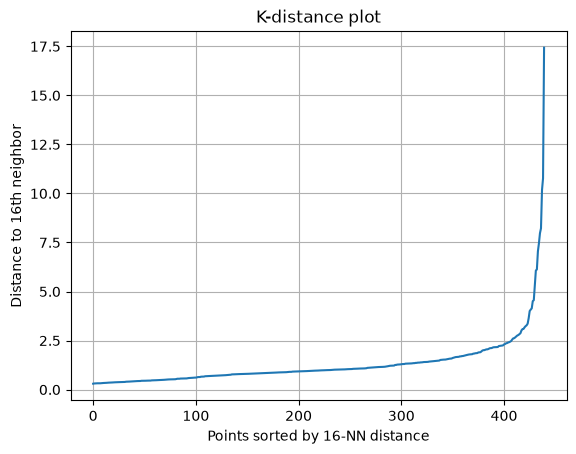

In [26]:
plt.plot(k_dist)
plt.xlabel("Points sorted by 16-NN distance")
plt.ylabel("Distance to 16th neighbor")
plt.title("K-distance plot")
plt.grid(True)
plt.show()

In [ ]:
# 2.3- 2.5  
from sklearn.cluster import DBSCAN
eps = 2.5 
dbscan = DBSCAN(eps = eps , min_samples = min_samples)
labels = dbscan.fit_predict(X_scaled_df)

X_clustered = X.copy()
X_clustered['cluster'] = labels
X_clustered.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,0


In [32]:
type(labels)
np.unique(labels) # -1 is a noise 
print(pd.Series(labels).value_counts().sort_index())
print("n_clusters =", len(set(labels)- {-1})) # removed the noise from the set
print("n_noise = ", (labels == -1).sum())


-1     14
 0    426
Name: count, dtype: int64
n_clusters = 1
n_noise =  14


In [36]:
# 2.4
# 2.3- 2.5  
from sklearn.cluster import DBSCAN
eps = 2.4
dbscan = DBSCAN(eps = eps , min_samples = min_samples)
labels1 = dbscan.fit_predict(X_scaled_df)

X_clustered = X.copy()
X_clustered['cluster'] = labels1
X_clustered.head()


type(labels1)
np.unique(labels1) # -1 is a noise 
print(pd.Series(labels1).value_counts().sort_index())
print("n_clusters =", len(set(labels1)- {-1})) # removed the noise from the set
print("n_noise = ", (labels1 == -1).sum())


-1     16
 0    424
Name: count, dtype: int64
n_clusters = 1
n_noise =  16


In [37]:
# 2.3

# 2.3- 2.5  
from sklearn.cluster import DBSCAN
eps = 2.3
dbscan = DBSCAN(eps = eps , min_samples = min_samples)
labels2 = dbscan.fit_predict(X_scaled_df)

X_clustered = X.copy()
X_clustered['cluster'] = labels2
X_clustered.head()


type(labels2)
np.unique(labels2) # -1 is a noise 
print(pd.Series(labels2).value_counts().sort_index())
print("n_clusters =", len(set(labels2)- {-1})) # removed the noise from the set
print("n_noise = ", (labels2 == -1).sum())



-1     17
 0    423
Name: count, dtype: int64
n_clusters = 1
n_noise =  17


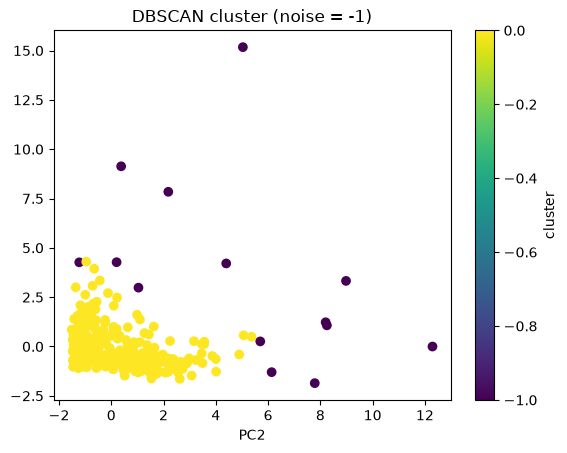

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled_df)
plt.scatter(X_pca[:,0], X_pca[:,1], c = labels)
plt.xlabel("PC1")
plt.xlabel("PC2")
plt.title("DBSCAN cluster (noise = -1)")
plt.colorbar(label = "cluster")
plt.show()

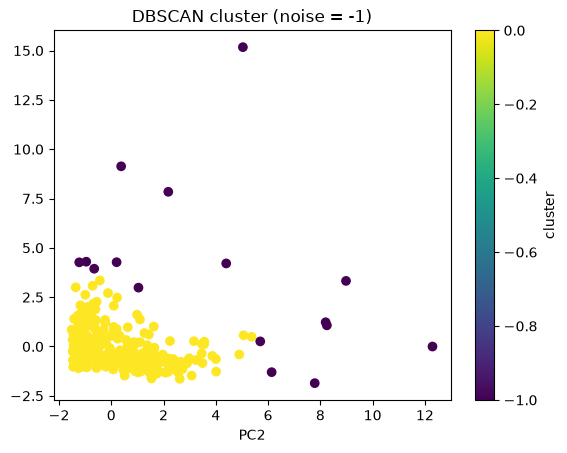

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled_df)
plt.scatter(X_pca[:,0], X_pca[:,1], c = labels1)
plt.xlabel("PC1")
plt.xlabel("PC2")
plt.title("DBSCAN cluster (noise = -1)")
plt.colorbar(label = "cluster")
plt.show()

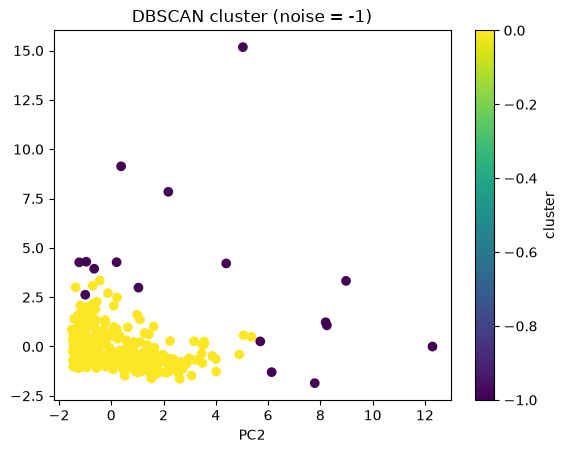

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled_df)
plt.scatter(X_pca[:,0], X_pca[:,1], c = labels2)
plt.xlabel("PC1")
plt.xlabel("PC2")
plt.title("DBSCAN cluster (noise = -1)")
plt.colorbar(label = "cluster")
plt.show()